In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import re

In [31]:
df = pd.read_csv('Amazon-Product-Reviews - Amazon Product Review (1).csv')

In [32]:
print(df.isnull().sum())
df = df.dropna(subset=["review_body", "sentiment"])

marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      2
review_body          4
review_date          0
sentiment            0
dtype: int64


In [33]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["full_text"] = df["review_headline"] + " " + df["review_body"]
df["clean_review"] = df["full_text"].apply(clean_text)


In [34]:
# Dropping uneccessary columns
df = df.drop(columns=[
    'marketplace',
    'product_parent',
    'review_id',
    'product_title',
    'product_category',
    'product_id'
], errors='ignore')

# Drop missing values
df = df.dropna(subset=['review_body', 'sentiment', 'review_headline'])

# Preview
print(df.head())

   customer_id  star_rating  helpful_votes  total_votes vine  \
0     11555559            5              0            0    N   
1     31469372            3              0            0    N   
2     26843895            5              0            0    N   
3     19844868            4              0            0    N   
4      1189852            5              0            0    N   

  verified_purchase                                    review_headline  \
0                 Y                                         Five Stars   
1                 N  Lots of ads Slow processing speed Occasionally...   
2                 Y                            Well thought out device   
3                 N  Not all apps/games we were looking forward to ...   
4                 Y                                         Five Stars   

                                         review_body review_date  sentiment  \
0                                      Great love it  2015-08-31          1   
1  Lots of a

Text(0, 0.5, 'Count')

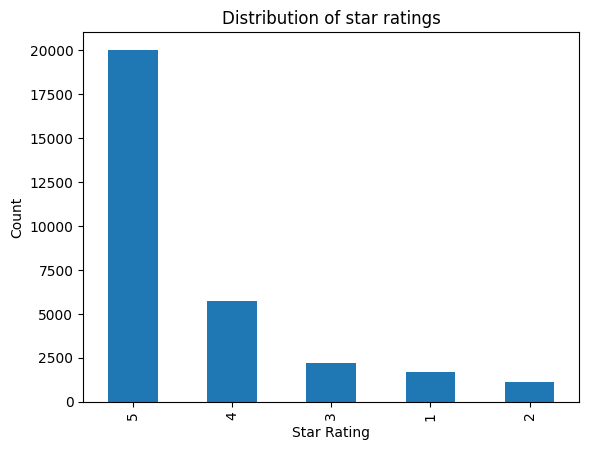

In [ ]:
#EDA
#rating distribution
df['star_rating'].value_counts().plot(kind='bar')
plt.title('Distribution of star ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count')

Text(0, 0.5, 'count')

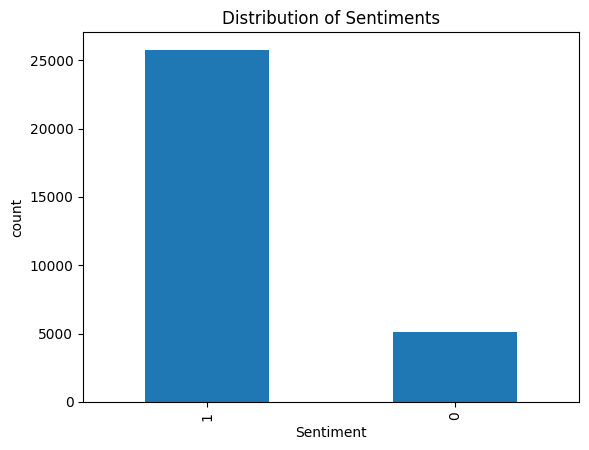

In [36]:
#sentiment distibution
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('count')

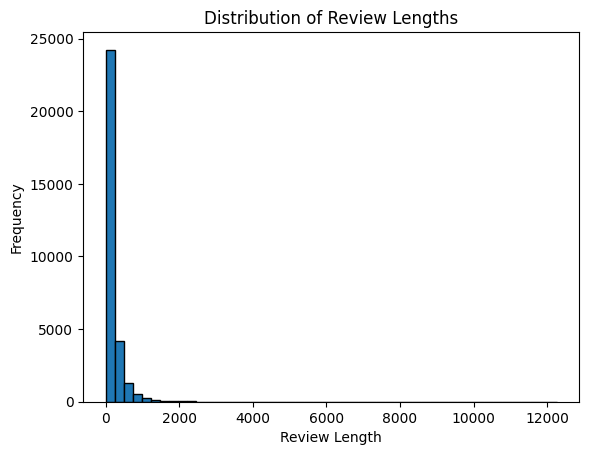

In [37]:
#review length
df['review_length'] = df['clean_review'].apply(len)
plt.hist(df['review_length'], bins=50, edgecolor='black')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')
plt.show()

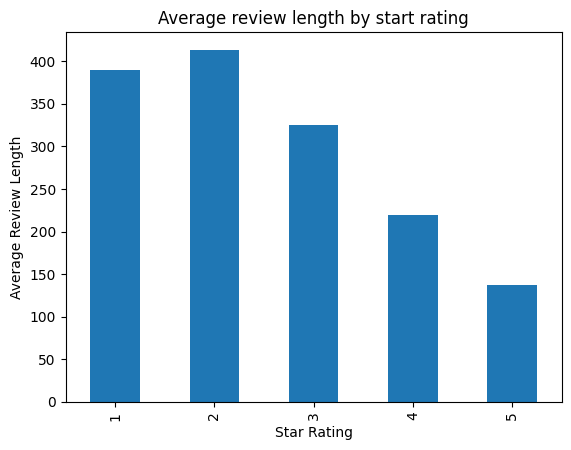

In [38]:
#rating vs length
df.groupby('star_rating')['review_length'].mean().plot(kind='bar')
plt.title('Average review length by start rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Review Length')
plt.show()

In [39]:
x = df['clean_review']
y= df['sentiment']

In [40]:
#splitting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
from sklearn.utils import resample

train_df = pd.DataFrame({'text': x_train, 'label': y_train})

majority = train_df[train_df.label == 1]
minority = train_df[train_df.label == 0]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

balanced_df = pd.concat([majority, minority_upsampled])

# Shuffle
balanced_df = balanced_df.sample(frac=1, random_state=42)

x_train_bal = balanced_df['text']
y_train_bal = balanced_df['label']

In [42]:
#vectorizing
tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.9
)

In [43]:
nb_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", MultinomialNB())
])

lr_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LogisticRegression(max_iter=1000))
])

svm_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", LinearSVC())
])


In [44]:
#naive bayes
nb_params = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_df": [0.8, 0.9, 1.0],
    "tfidf__min_df": [2, 5],
    "model__alpha": [0.1, 0.5, 1.0, 2.0]
}

In [45]:
#logistic regression
lr_params = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_df": [0.8, 0.9],
    "tfidf__min_df": [2, 5],
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear"]
}

In [46]:
#svm
svm_params = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_df": [0.8, 0.9],
    "tfidf__min_df": [2, 5],
    "model__C": [0.1, 1, 10]
}

In [47]:
grids = {}

models = [
    ("Naive Bayes", nb_pipeline, nb_params),
    ("Logistic Regression", lr_pipeline, lr_params),
    ("SVM", svm_pipeline, svm_params)
]

for name, pipeline, params in models:
    print(f"Training {name}...")

    grid = GridSearchCV(
        pipeline,
        params,
        cv=5,
        n_jobs=-1,
        scoring="f1_weighted"
    )

    grid.fit(x_train_bal, y_train_bal)

    grids[name] = grid

Training Naive Bayes...


Training Logistic Regression...
Training SVM...


In [ ]:
for name, grid in grids.items():
    print(f"\n{name}")
    print("Best Params:", grid.best_params_)

    y_pred = grid.predict(x_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Naive Bayes
Best Params: {'model__alpha': 2.0, 'tfidf__max_df': 0.8, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Accuracy: 0.8437094682230869
              precision    recall  f1-score   support

           0       0.51      0.87      0.65      1015
           1       0.97      0.84      0.90      5153

    accuracy                           0.84      6168
   macro avg       0.74      0.86      0.77      6168
weighted avg       0.90      0.84      0.86      6168

Confusion Matrix:
 [[ 888  127]
 [ 837 4316]]

Logistic Regression
Best Params: {'model__C': 10, 'model__solver': 'liblinear', 'tfidf__max_df': 0.8, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Accuracy: 0.8724059662775616
              precision    recall  f1-score   support

           0       0.58      0.84      0.68      1015
           1       0.97      0.88      0.92      5153

    accuracy                           0.87      6168
   macro avg       0.77      0.86      0.80      6168
weighted avg       0.90 

In [53]:
best_model = grids["Logistic Regression"].best_estimator_

In [54]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))

In [ ]:
import streamlit as st

# Load model 
model = pickle.load(open("model.pkl", "rb"))

# Text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

# Page config
st.set_page_config(
    page_title="Sentiment Analyzer 💬",
    page_icon="💜",
    layout="centered"
)

# UI Header

st.title("💬 Review Sentiment Analyzer")
st.markdown("Enter a product review and get instant sentiment prediction.")

# Input
user_input = st.text_area("Enter review text here:")

# Prediction
if st.button("Analyze ✨"):
    if not user_input.strip():
        st.warning("Type something first.")
    else:
        cleaned = clean_text(user_input)

        prediction = model.predict([cleaned])[0]

        # probability handling 
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba([cleaned])[0]
            confidence = max(proba) * 100
        else:
            confidence = None

        # Output
        if prediction == 1:
            if confidence:
                st.success(f"Positive 😊 ({confidence:.2f}% confidence)")
            else:
                st.success("Positive 😊")
        else:
            if confidence:
                st.error(f"Negative 😠 ({confidence:.2f}% confidence)")
            else:
                st.error("Negative 😠")

# Examples
st.divider()
st.subheader("💡 Try examples")

col1, col2 = st.columns(2)

with col1:
    if st.button("Good review"):
        st.write("I absolutely love this product. Works perfectly and exceeded expectations.")

with col2:
    if st.button("Bad review"):
        st.write("Terrible quality. Stopped working after two days and very disappointing.")

# Footer

st.markdown("---")
st.markdown("Built with ❤️ using Machine Learning")

2026-05-05 08:24:55.206 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 08:24:55.207 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 08:24:55.946 
  command:

    streamlit run C:\Users\Naomi Bosire\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-05 08:24:55.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 08:24:55.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 08:24:55.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 08:24:55.956 Thread 'MainThread': missing ScriptRunContext! This warnin

DeltaGenerator()